# Prédiction de matchs de ligue 1
Etudiants : Jean-Baptiste PASTEAU, Thomas NAUDY-NORMAND.

Voici notre projet pour le cours d'algorithmes d'apprentissage qui consiste à proposer une analyse qualitative du dataset donné et créer un modèle de prédiction des résultats de matchs de ligue 1 pour l'année 2025.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [6]:
clubs_fr = pd.read_csv("clubs_fr.csv")
game_events_before2025 = pd.read_csv("game_events_before2025.csv")
game_lineups = pd.read_csv("game_lineups.csv", dtype={'number': str})
matchs_2025 = pd.read_csv("match_2025.csv")
matchs_2013_2024 = pd.read_csv("matchs_2013_2024.csv")
player_appearance = pd.read_csv("player_appearance.csv")
player_valuation_before_season = pd.read_csv("player_valuation_before_season.csv")
sample_results = pd.read_csv("sample_results.csv")

## Présentation des données

- match_2013_2024.csv : La liste de tous les matchs avant le début de saison 2025-2026, avec le résultat associé
- match_2025.csv : La liste des matchs à prédire pour la saison 2025-2026, vous n’avez pas le résultat, il sera dévoilé après la fin du projet.
- sample_results.csv : un exemple de fichier de prédiction que j’attends pour tester votre modèle. À chaque id de match est associé un résultat (-1 0 ou 1)

- clubs_fr.csv : Une liste des clubs français avec quelques stats sur la constitution (récente) de l’équipe
- player_valuation_before_season.csv : Pour chaque joueur, sa valeur sur le marché, à une certaine date, à vous de transformer et d’utiliser cette information à bonne escient.
- player_appearance.csv : Un ensemble d’info simple sur chaque joueur pendant chaque match (nombre de buts, nombre de cartons)
- game_lineups.csv : La constitution des équipes pour chaque match, vous n’avez pas la constitution pour les matchs récents.
- game_events.csv :  Un ensemble d’actions pour chaque joueur pendant chaque match, peut compléter les informations sur un joueur, vous allez sûrement devoir aggreger des informations ce jeu (par exemple comptez le nombre de passe décisive, d’arrêt etc...)

## Analyse quantitative

Pour bien comprendre ce qu'on va chercher à prédire dans la suite on peut visualiser la distribution des résultats (-1, 0, 1) sur la période 2013 à 2024 en fonction de différents facteurs: le lieu du match (domicile/extérieur), la formation, l'entraîneur, la valeur marchande de l'équipe.

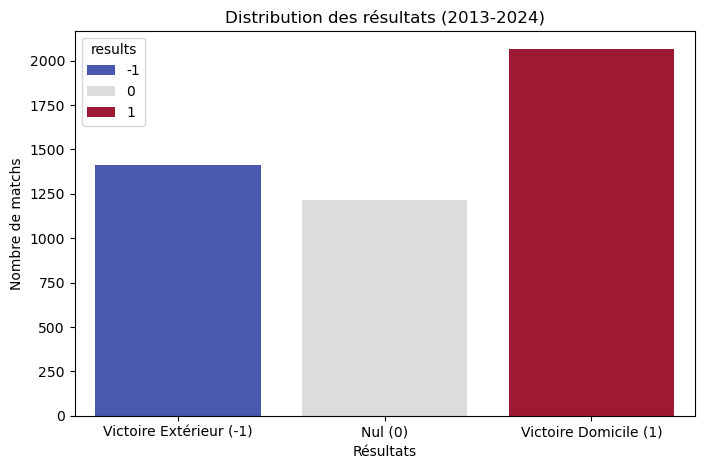

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(x='results', data=matchs_2013_2024, palette='coolwarm', hue='results')
plt.title('Distribution des résultats (2013-2024)')
plt.xticks(ticks=[0,1,2], labels=['Victoire Extérieur (-1)', 'Nul (0)', 'Victoire Domicile (1)'])
plt.xlabel('Résultats')
plt.ylabel('Nombre de matchs')
plt.show()

In [13]:
counts = matchs_2013_2024['results'].value_counts(normalize=True) * 100
home_stats = {
    'Victoire': counts.get(1, 0),
    'Nul': counts.get(0, 0),
    'Défaite': counts.get(-1, 0)
}

print(f"Stats Domicile : {home_stats['Victoire']:.2f}% Victoires, {home_stats['Nul']:.2f}% Nuls, {home_stats['Défaite']:.2f}% Défaites")

Stats Domicile : 44.02% Victoires, 25.92% Nuls, 30.06% Défaites


On observe qu'un match joué à domicile a une probabilité de victoire de 44.02%, de nul de 25.92% et de défaite de 30.06%. On voit bien que le lieu de la rencontre a un impact significatif sur l'issue du match.

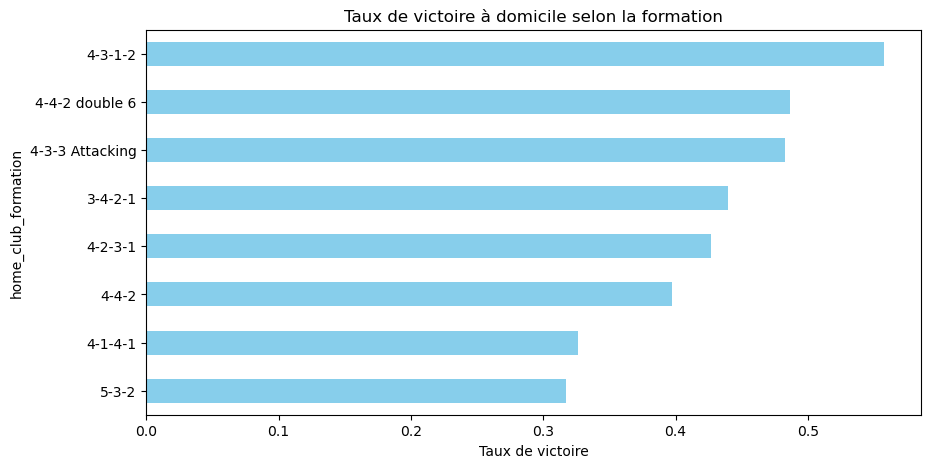

In [19]:
top_forms = matchs_2013_2024['home_club_formation'].value_counts().nlargest(8).index
df_form = matchs_2013_2024[matchs_2013_2024['home_club_formation'].isin(top_forms)]

form_stats = df_form.groupby('home_club_formation')['results'].apply(lambda x: (x == 1).mean())

plt.figure(figsize=(10, 5))
form_stats.sort_values().plot(kind='barh', color='skyblue')
plt.title('Taux de victoire à domicile selon la formation')
plt.xlabel('Taux de victoire')
plt.show()

En observant le taux de victoires des formations on remarque que certaines se démarquent par une plus grande efficacité par exemple pour la 4-3-1-2, 4-4-2, 4-3-3 en comparaison avec la formation 5-3-2.

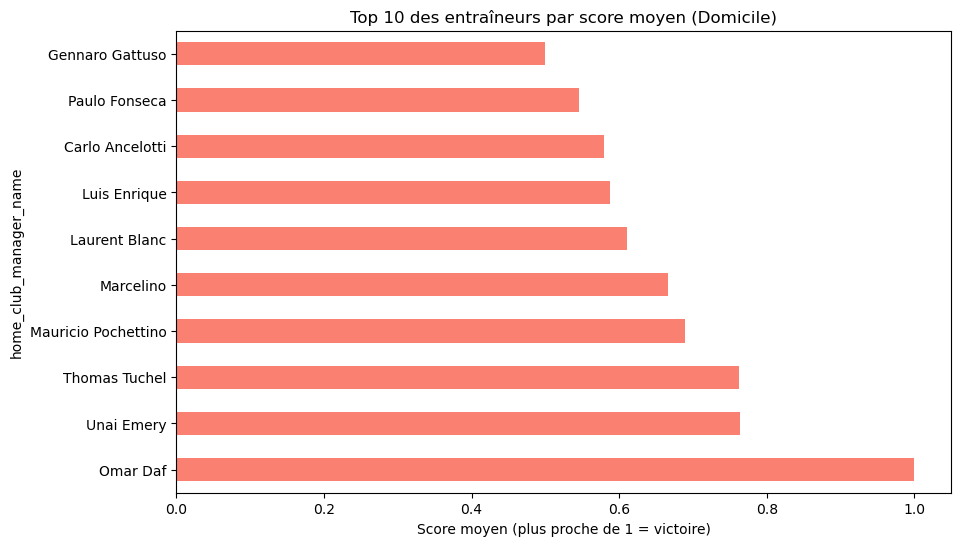

In [17]:
coach_perf = matchs_2013_2024.groupby('home_club_manager_name')['results'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
coach_perf.head(10).plot(kind='barh', color='salmon')
plt.title('Top 10 des entraîneurs par score moyen (Domicile)')
plt.xlabel('Score moyen (plus proche de 1 = victoire)')
plt.show()

L'efficacité de l'entraîneur est une information qui n'est pas particulièrement pertinente, car elle est grandement liée à l'équipe en elle-même. Le top 10 qu'on tire des données 2013-2024 est composé à 60% d'entraîneurs du PSG. Elle est aussi biaisée par la durée d'activité, Omar Daf ayant 1 car il a entraîné le FC Sochaux seulement 2 matchs en ligue 1 en 2012/2013. De plus, les entraîneurs changent régulièrement alors il y a peu d'intérêt à utiliser leur efficacité pour le modèle de prédiction.

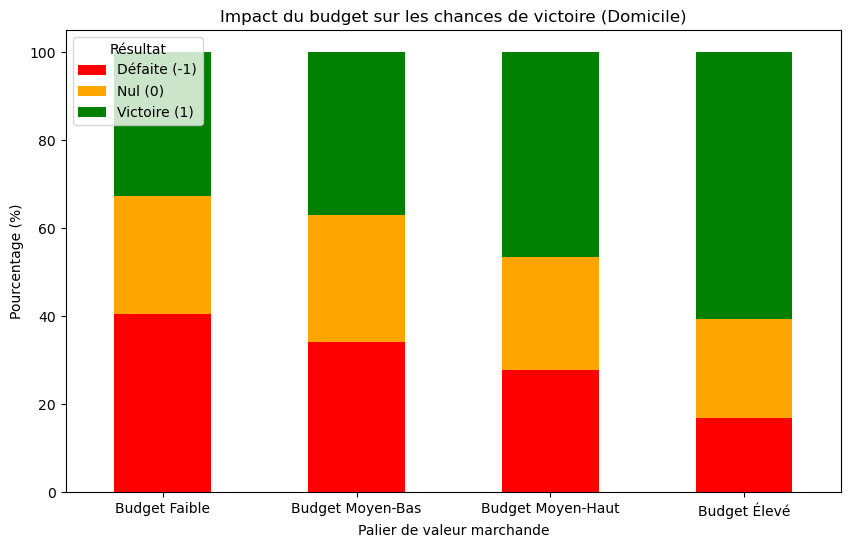

In [28]:
club_val_avg = player_valuation_before_season.groupby('current_club_id')['market_value_in_eur'].mean()

matchs_2013_2024['home_val'] = matchs_2013_2024['home_club_id'].map(club_val_avg)

matchs_2013_2024['budget_tier'] = pd.qcut(matchs_2013_2024['home_val'], 4,
                                          labels=['Budget Faible', 'Budget Moyen-Bas', 'Budget Moyen-Haut', 'Budget Élevé'])

df_grouped = matchs_2013_2024.groupby(['budget_tier', 'results'], observed=False).size().unstack(fill_value=0)
df_pct = df_grouped.div(df_grouped.sum(axis=1), axis=0) * 100

ax = df_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'orange', 'green'])
plt.title('Impact du budget sur les chances de victoire (Domicile)')
plt.ylabel('Pourcentage (%)')
plt.xlabel('Palier de valeur marchande')
plt.legend(title="Résultat", labels=['Défaite (-1)', 'Nul (0)', 'Victoire (1)'], loc='upper left')
plt.xticks(rotation=0)
plt.show()

On observe que la valeur marchande de l'équipe a un grand impact sur son taux de victoires/nuls/défaites. Plus la valeur marchande est élevée, plus l'équipe gagne.

Pour aller un peu plus loin, on sait aussi que les résultats sont aussi influencées par leur propre forme du moment. Par exemple, si l'équipe gagne depuis 3 matchs d'affilé, il est plus probable que le résultat du match leur soit favorable.

Pour le graphique ci-dessous, on calcule le taux de victoire sur les 5 derniers matchs afin d'établir l'état "psychologique" de l'équipe. Les catégories de formes sont :
- Faible : 0% à 20% de victoires
- Moyenne : 20% à 50% de victoires
- Bonne : 50% à 80% de victoires
- Excellente : 80% à 100% de victoires.

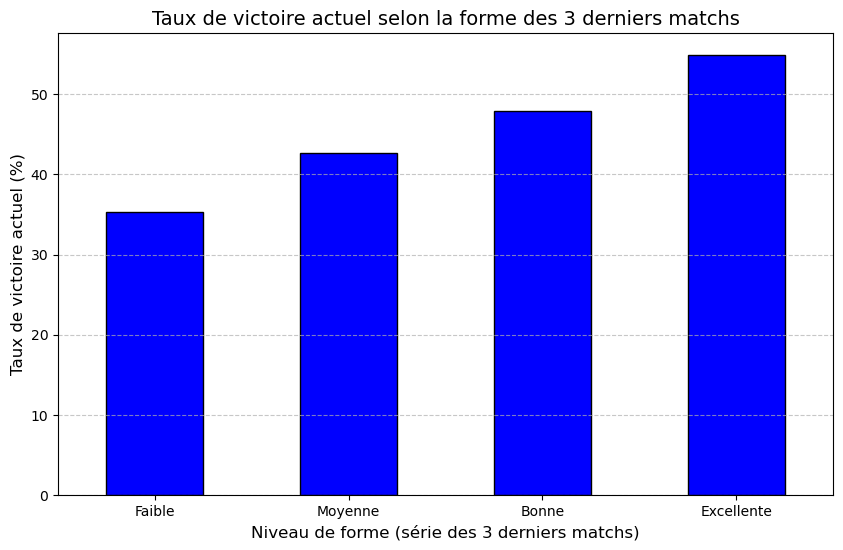

In [30]:
matchs_2013_2024['form_category'] = pd.cut(
    matchs_2013_2024['form_3_games'],
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=['Faible', 'Moyenne', 'Bonne', 'Excellente'],
    include_lowest=True
)

form_impact = matchs_2013_2024.groupby('form_category', observed=False)['is_win'].mean() * 100

plt.figure(figsize=(10, 6))
form_impact.plot(kind='bar', color='blue', edgecolor='black')

plt.title('Taux de victoire actuel selon la forme des 3 derniers matchs', fontsize=14)
plt.xlabel('Niveau de forme (série des 3 derniers matchs)', fontsize=12)
plt.ylabel('Taux de victoire actuel (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()